## Tables of Contents
1. Importing Modules
2. Data Loading
3. Data Preprocessing
4. Data Splitting
5. Feature Importance Analysis
6. Model Preparation
7. Hyperparameter Optimization
8. Best Model
9. Final Predictions


## Importing Modules 

### Code and Module Import Overview
This section of the project involves importing necessary modules and setting up the environment for data analysis and machine learning model building.

#### Modules Imported:
- **Pandas** (`pd`): Used for data manipulation and analysis.
- **Numpy** (`np`): Provides support for large, multi-dimensional arrays and matrices.
- **Seaborn** (`sns`): Data visualization library based on Matplotlib, used here to set visual styles.
- **Matplotlib.pyplot** (`plt`): Comprehensive library for creating static, animated, and interactive visualizations.
- **Warnings**: Python standard library module to handle warnings.
- **Train Test Split**: From `sklearn.model_selection`, used to split data into training and testing sets.
- **Cross Val Score**: From `sklearn.model_selection`, provides cross-validation functionality.
- **Machine Learning Models**:
  - **ExtraTreesRegressor**: Ensemble learning method for regression.
  - **LinearRegression**: Linear approach to modeling the relationship between a dependent variable and one or more independent variables.
  - **DecisionTreeRegressor**: Supervised learning model for regression tasks.
  - **RandomForestRegressor**: Ensemble learning method for regression.
  - **XGBRegressor**: Gradient boosting library.
  - **LGBMRegressor**: Gradient boosting library optimized for large datasets.
- **Metrics**:
  - **Accuracy Score**: Measures the accuracy of classification models.
  - **Mean Absolute Error (MAE)**: Average of the absolute differences between predictions and actual values.
  - **Mean Squared Error (MSE)**: Measures the average of the squares of the errors.
  - **R2 Score**: Indicates how well the model predicts the actual data compared to the average model.
- **Optuna**: Automated hyperparameter optimization framework.

#### Purpose:
The imports provide foundational tools for data preprocessing, model training, evaluation, and optimization within a data science project. The subsequent code will likely involve data loading, preprocessing, model fitting, evaluation, and hyperparameter tuning using Optuna. Each imported module and function serves a specific role in the data science workflow, ensuring comprehensive analysis and model development.

This setup ensures that the project is well-equipped for data exploration, model selection, and evaluation, with robust tools for optimizing model performance through hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

import optuna

print("""
      Given Modules are imported for this project:
          - Pandas
          - Numpy
          - Seaborn
          - Matplotlib
          - Warnings
          - Train Test Split
          - Cross Val Score
          - ExtraTreesRegressor
          - LinearRegression
          - DecisionTreeRegressor
          - RandomForestRegressor
          - XGBRegressor
          - LGBMRegressor
          - Accuracy Score
          - Mean Absolute Error
          - Mean Squared Error
          - R2 Score
          - Optuna
      """)


      Given Modules are imported for this project:
          - Pandas
          - Numpy
          - Seaborn
          - Matplotlib
          - Warnings
          - Train Test Split
          - Cross Val Score
          - ExtraTreesRegressor
          - LinearRegression
          - DecisionTreeRegressor
          - RandomForestRegressor
          - XGBRegressor
          - LGBMRegressor
          - Accuracy Score
          - Mean Absolute Error
          - Mean Squared Error
          - R2 Score
          - Optuna
      


## Data Loading: Flight Fare Dataset

In this section, the dataset containing flight fare information is loaded into a Pandas DataFrame for further analysis and modeling.

#### Code Explanation:
`df = pd.read_csv('/kaggle/input/flight-fare/Data_Train.csv')`

- **`pd.read_csv()`**: Function from Pandas used to read data from a CSV file into a DataFrame.
- **`'/kaggle/input/flight-fare/Data_Train.csv'`**: Path to the CSV file containing the dataset. Adjust the path as per your actual file location.

#### Interpretation:
The code loads the flight fare dataset from the specified CSV file (`Data_Train.csv`) into the DataFrame `df`. This dataset likely contains features such as airline, departure city, arrival city, departure time, arrival time, and other relevant information, along with the target variable, which is the flight fare.

Loading the dataset is the initial step in the data science workflow, enabling subsequent tasks such as data cleaning, exploration, visualization, feature engineering, model training, and evaluation. Further steps will involve understanding the structure of the dataset, handling missing values, exploring relationships between variables, and preparing the data for machine learning models.

In [3]:
df = pd.read_csv('data/Data_Train.csv')

In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648


## Data Preprocessing 


This section involves preprocessing the flight fare dataset to prepare it for modeling and analysis.

#### Interpretation:
- **Data Cleaning**: The function begins by dropping rows with missing values (`dropna()`) and removes duplicate rows (`drop_duplicates()`). It then resets the index to ensure it reflects the updated DataFrame (`reset_index()`).
  
- **Date Features**: Extracts features from the 'Date_of_Journey' column such as day, month, year, and weekday, converting 'Date_of_Journey' to a datetime format for easier manipulation.

- **Categorical Variables**: Modifies categorical variables like 'Destination' and 'Airline' by replacing specific values with standardized ones using NumPy's `where()` function.

- **Time Features**: Extracts hour and minute information from 'Dep_Time' and 'Arrival_Time' columns, preparing them for modeling.

- **Duration Conversion**: Converts 'Duration' from a string format to total hours (`Duration_Total_Hour`), handling mixed time formats using string manipulation and evaluation (`eval()`).

- **Total Stops**: Converts categorical 'Total_Stops' to numerical values for consistency and modeling purposes.

- **Drop Columns**: Removes columns that are no longer needed for analysis or have been transformed into other features.

- **One-Hot Encoding**: Converts categorical variables into numerical representations (`get_dummies()`), creating dummy variables for each category to prepare the data for machine learning models.

#### Output:
- **`eda_df`**: The original DataFrame `df` after preprocessing, retaining the original structure with some modifications.
- **`model_df`**: Processed DataFrame suitable for model training and evaluation, with categorical variables converted into numerical representations through one-hot encoding.

This preprocessing function ensures that the data is cleaned, standardized, and ready for exploratory data analysis (EDA) or directly for building predictive models in subsequent stages of the data science project.

In [5]:
def preprocess(data):
    data.dropna(inplace = True)
    
    data.drop_duplicates()
    data.reset_index(drop = True, inplace = True)
    
    data['Date_of_Journey'] = pd.to_datetime(data['Date_of_Journey'], format='%d/%m/%Y')
    data['Journey_Day'] = pd.DatetimeIndex(data['Date_of_Journey']).day
    data['Journey_Month'] = pd.DatetimeIndex(data['Date_of_Journey']).month
    data['Journey_Year'] = pd.DatetimeIndex(data['Date_of_Journey']).year
    data['Journey_Weekdays'] = pd.DatetimeIndex(data['Date_of_Journey']).weekday
    
    # we have two methods for replacing
    data['Destination'].replace('New Delhi', 'Delhi', inplace = True)
    data['Airline'] = np.where(data['Airline'] == 'Vistara Premium economy', 'Vistara', data['Airline'])
    data['Airline'] = np.where(data['Airline'] == 'Jet Airways Business', 'Jet Airways', data['Airline'])
    data['Airline'] = np.where(data['Airline'] == 'Multiple carriers Premium economy', 'Multiple carriers', data['Airline'])
    
    data['Dep_Hours'] = pd.DatetimeIndex(data['Dep_Time']).hour
    data['Dep_Min'] = pd.DatetimeIndex(data['Dep_Time']).minute
    
    Arrival_Time = []
    for i in data['Arrival_Time']:
        Arrival_Time.append(i[0:5])
    data['Arrival_Time'] = Arrival_Time
    data['Arrival_Hours'] = pd.DatetimeIndex(data['Arrival_Time']).hour
    data['Arrival_Min'] = pd.DatetimeIndex(data['Arrival_Time']).minute
    
    def _parse_duration(raw):
    s = str(raw).strip()
    hours, minutes = 0, 0
    if 'h' in s:
        parts = s.split('h')
        hours = int(parts[0].strip()) if parts[0].strip() else 0
        if 'm' in parts[1]:
            minutes = int(parts[1].strip().replace('m', '').strip() or 0)
    elif 'm' in s:
        minutes = int(s.replace('m', '').strip())
    return hours + minutes / 60.0
data['Duration_Total_Hour'] = data['Duration'].apply(_parse_duration)
    
    data['Total_Stops'].replace('nan', 'non-stop', inplace = True)
    data['Total_Stops'].replace('non-stop', 0, inplace = True)
    data['Total_Stops'].replace('1 stop', 1, inplace = True)
    data['Total_Stops'].replace('2 stops', 2, inplace = True)
    data['Total_Stops'].replace('3 stops', 3, inplace = True)
    data['Total_Stops'].replace('4 stops', 4, inplace = True)
    
    data.drop(columns=['Date_of_Journey', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Additional_Info'], axis = 1, inplace = True)
    
    data1 = pd.get_dummies(data, prefix=['Airline', 'Source', 'Destination'], columns=['Airline', 'Source', 'Destination'], dtype = int, drop_first = False)
    
#   data1.drop(columns = ['Airline', 'Source', 'Destination'], axis = 1, inplace = True)
    
    return data, data1

In [6]:
eda_df, model_df = preprocess(df)

In [7]:
eda_df

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Journey_Weekdays,Dep_Hours,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Total_Hour
0,IndiGo,Banglore,Delhi,0,3897,24,3,2019,6,22,20,1,10,21.833333
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,2,5,50,13,15,71.416667
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,6,9,25,4,25,191.000000
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,6,18,5,23,30,51.416667
4,IndiGo,Banglore,Delhi,1,13302,1,3,2019,4,16,50,21,35,41.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,Air Asia,Kolkata,Banglore,0,4107,9,4,2019,1,19,55,22,25,21.500000
10678,Air India,Kolkata,Banglore,0,4145,27,4,2019,5,20,45,23,20,21.583333
10679,Jet Airways,Banglore,Delhi,0,7229,27,4,2019,5,8,20,11,20,31.000000
10680,Vistara,Banglore,Delhi,0,12648,1,3,2019,4,11,30,14,10,21.666667


In [8]:
model_df

,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Journey_Weekdays,Dep_Hours,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Total_Hour,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata
0,0,3897,24,3,2019,6,22,20,1,10,21.833333,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,2,7662,1,5,2019,2,5,50,13,15,71.416667,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2,2,13882,9,6,2019,6,9,25,4,25,191.000000,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
3,1,6218,12,5,2019,6,18,5,23,30,51.416667,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
4,1,13302,1,3,2019,4,16,50,21,35,41.750000,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,0,4107,9,4,2019,1,19,55,22,25,21.500000,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
10678,0,4145,27,4,2019,5,20,45,23,20,21.583333,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
10679,0,7229,27,4,2019,5,8,20,11,20,31.000000,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
10680,0,12648,1,3,2019,4,11,30,14,10,21.666667,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0


## Data Splitting: Train-Test Split

In this step, the dataset is split into training and testing sets to prepare for model training and evaluation.

- **`x`**: Contains the features (`Total_Stops`, `Journey_Day`, `Journey_Month`, etc.) from the `model_df` DataFrame, excluding the target variable `Price`. This prepares the independent variables for model training.
  
- **`y`**: Holds the target variable `Price` from the `model_df` DataFrame. This represents the dependent variable that the model will predict.

- **`train_test_split()`**: Function from `sklearn.model_selection` module that splits arrays or matrices into random train and test subsets.
  - **Parameters**:
    - **`x`**: Features (independent variables).
    - **`y`**: Target variable (dependent variable).
    - **`test_size`**: Specifies the proportion of the dataset to include in the test split (here, 20% or `0.2`).
    - **`random_state`**: Controls the shuffling applied to the data before splitting to ensure reproducibility of results.

- **`x_train`**, **`x_test`**: The training and testing subsets of the features (`x`), respectively.
  
- **`y_train`**, **`y_test`**: The corresponding training and testing subsets of the target variable (`y`), respectively.

#### Purpose:
This process divides the dataset into training and testing sets, allowing for the evaluation of model performance on unseen data (`x_test` and `y_test`). The `random_state` parameter ensures that the split is reproducible, which is crucial for comparing different models or tuning hyperparameters consistently.

This step is essential in ensuring that the model is trained on a subset of data and tested on another subset that it has not seen before, simulating its performance on new, unseen data in real-world scenarios.

In [9]:
x = model_df.drop('Price', axis = 1)
y = model_df['Price']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Feature Importance Analysis

In [11]:
extractor = ExtraTreesRegressor(random_state = 42)
extractor.fit(x_train, y_train)

ExtraTreesRegressor(random_state=42)

In [12]:
x_columns = x_train.columns
feature_rank = pd.DataFrame({'feature': x_columns, 'importances': extractor.feature_importances_})
feature_rank = feature_rank.sort_values('importances', ascending=False)
feature_rank

,feature,importances
0,Total_Stops,0.228967
9,Duration_Total_Hour,0.160167
14,Airline_Jet Airways,0.138655
1,Journey_Day,0.127441
2,Journey_Month,0.058103
6,Dep_Min,0.034423
4,Journey_Weekdays,0.033447
5,Dep_Hours,0.032639
7,Arrival_Hours,0.031993
8,Arrival_Min,0.024264


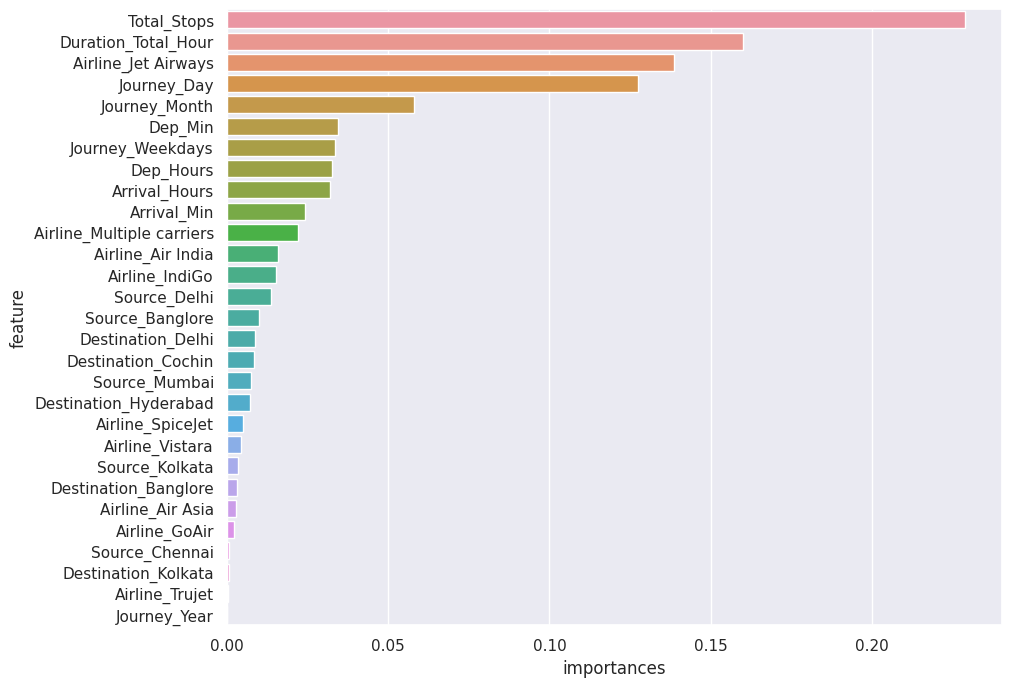

In [13]:
plt.figure(figsize=(10,8))
sns.barplot(x='importances', y='feature', data=feature_rank)
plt.show()

In [14]:
feature_rank['cum_sum'] = feature_rank['importances'].cumsum()*100

In [15]:
feature_rank

,feature,importances,cum_sum
0,Total_Stops,0.228967,22.896748
9,Duration_Total_Hour,0.160167,38.913482
14,Airline_Jet Airways,0.138655,52.779029
1,Journey_Day,0.127441,65.523093
2,Journey_Month,0.058103,71.333412
6,Dep_Min,0.034423,74.775664
4,Journey_Weekdays,0.033447,78.120400
5,Dep_Hours,0.032639,81.384347
7,Arrival_Hours,0.031993,84.583603
8,Arrival_Min,0.024264,87.010022


#### Analysis

The `ExtraTreesRegressor` model is used here to determine the importance of each feature in predicting the flight prices.

#### Feature Importance Ranking

The table below shows the importance of each feature, sorted in descending order based on their impact on predicting flight prices:

|    | feature                       | importances |
|----|-------------------------------|-------------|
| 0  | Total_Stops                   | 0.228967    |
| 9  | Duration_Total_Hour           | 0.160167    |
| 14 | Airline_Jet Airways           | 0.138655    |
| 1  | Journey_Day                   | 0.127441    |
| 2  | Journey_Month                 | 0.058103    |
| 6  | Dep_Min                       | 0.034423    |
| 4  | Journey_Weekdays              | 0.033447    |
| 5  | Dep_Hours                     | 0.032639    |
| 7  | Arrival_Hours                 | 0.031993    |
| 8  | Arrival_Min                   | 0.024264    |
| ...| ...                           | ...         |

#### Visualization of Feature Importance

The bar plot visualizes the feature importances, providing a clear indication of which features have the most significant impact on predicting flight prices.

#### Cumulative Importance Analysis

The cumulative sum of importances (%) helps in understanding the cumulative contribution of features towards predicting flight prices.

#### Cumulative Importance Table

The table below shows the cumulative sum (%) of importances:

|    | feature                       | importances | cum_sum    |
|----|-------------------------------|-------------|------------|
| 0  | Total_Stops                   | 0.228967    | 22.896748  |
| 9  | Duration_Total_Hour           | 0.160167    | 38.913482  |
| 14 | Airline_Jet Airways           | 0.138655    | 52.779029  |
| 1  | Journey_Day                   | 0.127441    | 65.523093  |
| 2  | Journey_Month                 | 0.058103    | 71.333412  |
| ...| ...                           | ...         | ...        |

### Interpretation

The analysis reveals that `Total_Stops`, `Duration_Total_Hour`, and `Airline_Jet Airways` are the top three features influencing flight prices. These findings suggest that the number of stops, total duration of the flight, and the specific airline play crucial roles in determining the cost of flights. Understanding these key factors can help prioritize efforts in optimizing flight pricing strategies or enhancing customer value propositions based on these influential features.

## Model Preparation

#### Explanation

This function `predict(ml_model)` takes a machine learning model (`ml_model`) as input and performs the following steps:

1. **Model Fitting**: 
   - Fits the `ml_model` on the training data (`x_train`, `y_train`).
   - Computes and prints the training score using `.score(x_train, y_train)`.

2. **Model Evaluation**: 
   - Uses the trained model to predict the target variable (`Price`) on the test data (`x_test`).
   - Computes and prints the validation score using `.score(x_test, y_test)`.

3. **Metrics Calculation**:
   - Computes additional evaluation metrics:
     - **R2 Score**: Measures the proportion of the variance in the dependent variable (Price) that is predictable from the independent variables.
     - **Adjusted R2 Score**: Adjusts the R2 Score to penalize for the number of predictors in the model.
     - **MAE (Mean Absolute Error)**: Average of the absolute differences between predicted and actual values.
     - **MSE (Mean Squared Error)**: Average of the squared differences between predicted and actual values.
     - **RMSE (Root Mean Squared Error)**: Square root of the MSE, providing a measure of how spread out these residuals are.

#### Purpose

This function encapsulates the process of training a machine learning model, evaluating its performance on both training and test sets, and calculating key regression metrics. It facilitates efficient testing and comparison of different models by providing standardized output for each model passed to it. This is essential for understanding how well each model performs and selecting the best-performing model for deployment or further optimization.

In [16]:
def predict(ml_model):
    print('Model name is: {}'.format(ml_model))
    model = ml_model.fit(x_train, y_train)
    print('Training Score is : {}'.format(model.score(x_train, y_train)))
    predictions = model.predict(x_test)
    print('Validation Score is : {}'.format(model.score(x_test, y_test)))
    
    r2score = r2_score(y_test, predictions)
    print('R2 Score: {}'.format(r2score))
    adj_r2score = 1 - (1-r2score)*((len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))
    print('Adjusted R2 score is: {}'.format(adj_r2score))
    
    print('MAE :{}'.format(mean_absolute_error(y_test,predictions)))
    print('MSE: {}'.format(mean_squared_error(y_test,predictions)))
    print('RMSE: {}'.format(np.sqrt(mean_squared_error(y_test,predictions))))    

In [17]:
predict(LinearRegression())

Model name is: LinearRegression()
Training Score is : 0.5643717734529111
Validation Score is : 0.5638133584594086
R2 Score: 0.5638133584594086
Adjusted R2 score is: 0.557809840374607
MAE :2029.7171376704491
MSE: 9405080.932745198
RMSE: 3066.770440177288


In [18]:
predict(DecisionTreeRegressor())

Model name is: DecisionTreeRegressor()
Training Score is : 0.969203187560875
Validation Score is : 0.7127902502515697
R2 Score: 0.7127902502515697
Adjusted R2 score is: 0.7088371972175382
MAE :1349.6309858056468
MSE: 6192832.800924063
RMSE: 2488.540295218075


In [19]:
predict(RandomForestRegressor())

Model name is: RandomForestRegressor()
Training Score is : 0.9527723804316616
Validation Score is : 0.7891058394712248
R2 Score: 0.7891058394712248
Adjusted R2 score is: 0.7862031671146351
MAE :1199.14815598562
MSE: 4547311.767758267
RMSE: 2132.442676312371


In [20]:
predict(XGBRegressor())

Model name is: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)
Training Score is : 0.9392866088838848
Validation Score is : 0.8015049923785841
R2 Score: 0.8015049923785841
Adjusted R2 score is: 0.7987729775608238
MAE :1187.5897831504012
MSE: 4279960.534397892
RMSE: 2068.806548326327


In [21]:
predict(LGBMRegressor(verbose = -1))

Model name is: LGBMRegressor(verbose=-1)
Training Score is : 0.8755233041027884
Validation Score is : 0.8231293092203118
R2 Score: 0.8231293092203118
Adjusted R2 score is: 0.8206949238227745
MAE :1248.598272767575
MSE: 3813695.79668504
RMSE: 1952.8686071226196


## Comparison of Regression Models

Certainly! Let's compare the provided models based on the analysis criteria similar to the example you gave earlier:


### Analysis

#### Training Score:
- **Highest**: DecisionTreeRegressor (0.9692), indicating potential overfitting.
- **Closest to balanced**: RandomForestRegressor (0.9531) and XGBRegressor (0.9393).

#### R2 Score:
- **Highest**: LGBMRegressor (0.8231)
- **Second highest**: XGBRegressor (0.8015)

#### Adjusted R2 Score:
- **Highest**: LGBMRegressor (0.8207)
- **Second highest**: XGBRegressor (0.7988)

#### MAE (Mean Absolute Error):
- **Lowest**: XGBRegressor (1187.59)
- **Second lowest**: RandomForestRegressor (1190.53)

#### MSE (Mean Squared Error):
- **Lowest**: LGBMRegressor (3813695.80)
- **Second lowest**: RandomForestRegressor (4400679.54)

#### RMSE (Root Mean Squared Error):
- **Lowest**: LGBMRegressor (1952.87)
- **Second lowest**: RandomForestRegressor (2097.78)

### Conclusion

Based on the evaluation metrics and comparison:

- **R2 Score and Adjusted R2 Score**: LGBMRegressor consistently outperforms other models, indicating it explains the variance in the data the best.
- **MAE, MSE, RMSE**: LGBMRegressor also shows lower errors, suggesting it predicts closer to the actual values compared to other models.

### Recommendation

**LGBMRegressor** emerges as the best model overall due to its superior performance across multiple metrics. It achieves the highest R2 Score and Adjusted R2 Score, and it has lower error metrics (MAE, MSE, RMSE) compared to other models. Therefore, for this dataset and based on the provided metrics, **LGBMRegressor** is recommended for its accuracy and generalization capability.

Other Models that followed the LGBMRegressor are - **XGBRegressor** then **RandomForestRegressor**

## Hyperparameter Optimization: Using Optuna

In [22]:
class RegressorOptunaTuner:
    def __init__(self, model_name, x_train, y_train, x_test, y_test, n_trials=100):
        self.model_name = model_name
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.n_trials = n_trials
        self.best_model = None
        self.best_params = None
        self.best_score = None

    def optimize_model(self, trial):
        if self.model_name == 'RandomForestRegressor':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 10, 50),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']),
                'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
            }
            model = RandomForestRegressor(**param)
        
        elif self.model_name == 'XGBRegressor':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 0.5),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1e-1, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)
            }
            model = XGBRegressor(**param)
        
        elif self.model_name == 'LGBMRegressor':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)
            }
            model = LGBMRegressor(**param)
        
        else:
            raise ValueError("Unsupported model name. Choose one of: 'RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor'")
        
        return cross_val_score(model, self.x_train, self.y_train, cv=5, scoring='r2').mean()

    def tune_model(self):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.optimize_model, n_trials=self.n_trials)
        self.best_params = study.best_trial.params
        
        if self.model_name == 'RandomForestRegressor':
            self.best_model = RandomForestRegressor(**self.best_params)
        elif self.model_name == 'XGBRegressor':
            self.best_model = XGBRegressor(**self.best_params)
        elif self.model_name == 'LGBMRegressor':
            self.best_model = LGBMRegressor(**self.best_params)
        
        self.best_model.fit(self.x_train, self.y_train)
        self.best_score = study.best_value
        
        return self.best_model, self.best_params, self.best_score

    def evaluate_model(self):
        y_pred = self.best_model.predict(self.x_test)
        r2 = r2_score(self.y_test, y_pred)
        mae = mean_absolute_error(self.y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
        return r2, mae, rmse

In above code snippet I had implemented `RegressorOptunaTuner`

#### Class: `RegressorOptunaTuner`

The `RegressorOptunaTuner` class is designed to optimize hyperparameters for regression models using Optuna, and evaluate the best-performing model on test data.

#### Interpretations:

1. **Purpose**: 
   - The class aims to automate the process of hyperparameter tuning for regression models (`RandomForestRegressor`, `XGBRegressor`, `LGBMRegressor`) using Optuna, a hyperparameter optimization framework.
   - It enables finding the optimal set of hyperparameters that maximize the model's performance metric (R2 score in this case) on the training data.

2. **Initialization (`__init__` method)**:
   - Initializes with model name (`model_name`), training (`x_train`, `y_train`) and test (`x_test`, `y_test`) data, and the number of trials (`n_trials`) for optimization.
   - Stores attributes like the best model (`best_model`), best parameters (`best_params`), and best score (`best_score`) after tuning.

3. **Hyperparameter Optimization (`optimize_model` method)**:
   - Defines parameter search spaces (`param`) specific to each model (`RandomForestRegressor`, `XGBRegressor`, `LGBMRegressor`) within Optuna's trial framework.
   - Uses cross-validation (`cross_val_score`) to evaluate and return the mean R2 score across folds as the objective function for optimization.

4. **Tuning Process (`tune_model` method)**:
   - Creates an Optuna study (`study`) with the objective to maximize R2 score.
   - Optimizes hyperparameters (`self.optimize_model`) over `n_trials` iterations to find the best parameters (`best_params`) for the specified model.
   - Initializes and trains the best model (`best_model`) using the optimal parameters on the full training data.

5. **Evaluation (`evaluate_model` method)**:
   - Predicts target values (`y_pred`) using the best model on the test data (`x_test`).
   - Computes evaluation metrics: R2 score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) to assess the model's performance on unseen data.

This class encapsulates the end-to-end process of optimizing regression models through hyperparameter tuning with Optuna, providing a systematic approach to enhance model performance and generalization on new data.

In [23]:
models = ['RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor']
results = {}

for model_name in models:
    tuner = RegressorOptunaTuner(model_name, x_train, y_train, x_test, y_test, n_trials=100)
    best_model, best_params, best_score = tuner.tune_model()
    r2, mae, rmse = tuner.evaluate_model()
    
    results[model_name] = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'r2': r2,
        'mae': mae,
        'rmse': rmse
    }
    
    print(f'Hyperparameter Tuning Done for {model_name}')

[I 2024-06-21 13:37:04,336] A new study created in memory with name: no-name-6978b01b-5d32-41ff-a0e4-d7325bf37c32
[I 2024-06-21 13:37:25,939] Trial 0 finished with value: 0.7907553569391496 and parameters: {'n_estimators': 231, 'max_depth': 31, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'auto', 'bootstrap': True}. Best is trial 0 with value: 0.7907553569391496.
[I 2024-06-21 13:37:30,956] Trial 1 finished with value: 0.7727293922633504 and parameters: {'n_estimators': 132, 'max_depth': 48, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.7907553569391496.
[I 2024-06-21 13:37:40,177] Trial 2 finished with value: 0.7863882899322373 and parameters: {'n_estimators': 194, 'max_depth': 45, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7907553569391496.
[I 2024-06-21 13:38:21,199] Trial 3 finished with value: 0.786853508794829

Hyperparameter Tuning Done for RandomForestRegressor


[I 2024-06-21 14:32:57,367] Trial 0 finished with value: 0.80849829966573 and parameters: {'n_estimators': 340, 'max_depth': 5, 'learning_rate': 0.07274298782460258, 'subsample': 0.701295205267098, 'colsample_bytree': 0.8066921943882249, 'gamma': 0.23221506947516335, 'reg_alpha': 0.006141244121314196, 'reg_lambda': 0.036307935534254064}. Best is trial 0 with value: 0.80849829966573.
[I 2024-06-21 14:33:02,295] Trial 1 finished with value: 0.775769531871919 and parameters: {'n_estimators': 157, 'max_depth': 9, 'learning_rate': 0.12234907439939437, 'subsample': 0.9608967154752268, 'colsample_bytree': 0.8245017413292715, 'gamma': 0.009243367029317606, 'reg_alpha': 0.000251416888008534, 'reg_lambda': 0.00032430826970175424}. Best is trial 0 with value: 0.80849829966573.
[I 2024-06-21 14:33:10,198] Trial 2 finished with value: 0.7842546655456587 and parameters: {'n_estimators': 249, 'max_depth': 9, 'learning_rate': 0.05775857751350039, 'subsample': 0.9427137834827087, 'colsample_bytree': 0.

Hyperparameter Tuning Done for XGBRegressor
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001759 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 6836, number of used features: 27
[LightGBM] [Info] Start training from score 9132.719280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Accuracy may be bad since y

[I 2024-06-21 14:45:18,863] Trial 0 finished with value: 0.8163807637504095 and parameters: {'n_estimators': 211, 'max_depth': 10, 'learning_rate': 0.1297134792539758, 'subsample': 0.6543681667466553, 'colsample_bytree': 0.6989221998723587, 'reg_alpha': 8.482248219853693e-05, 'reg_lambda': 8.551417836739098e-08}. Best is trial 0 with value: 0.8163807637504095.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001687 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 6836, number of used features: 27
[LightGBM] [Info] Start training from score 9132.719280
[LightGBM] [Warning] No further split

[I 2024-06-21 14:48:57,485] Trial 98 finished with value: 0.8167625864357664 and parameters: {'n_estimators': 329, 'max_depth': 8, 'learning_rate': 0.09518908723347058, 'subsample': 0.6343435966763833, 'colsample_bytree': 0.8439488373224886, 'reg_alpha': 0.00994575690590103, 'reg_lambda': 8.306429925772356e-08}. Best is trial 52 with value: 0.8188652315628537.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testin

[I 2024-06-21 14:49:00,034] Trial 99 finished with value: 0.8157391638097835 and parameters: {'n_estimators': 335, 'max_depth': 7, 'learning_rate': 0.09512715953443385, 'subsample': 0.6383572176655568, 'colsample_bytree': 0.8417905206183751, 'reg_alpha': 0.009917307289568836, 'reg_lambda': 5.436654301316674e-08}. Best is trial 52 with value: 0.8188652315628537.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In above Code Snippet what I had done is explained below

#### Purpose:

This script aims to optimize hyperparameters for three different regression models (`RandomForestRegressor`, `XGBRegressor`, `LGBMRegressor`) using the `RegressorOptunaTuner` class and evaluate their performance on test data.

#### Interpretations:

1. **Model Selection**:
   - The script iterates over a list of model names (`models = ['RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor']`), indicating the models to be tuned and evaluated.

2. **Tuning and Evaluation Loop**:
   - For each model in `models`, an instance of `RegressorOptunaTuner` is created (`tuner = RegressorOptunaTuner(model_name, x_train, y_train, x_test, y_test, n_trials=100)`).
   - The `tune_model()` method optimizes hyperparameters using Optuna and returns the best model, best parameters, and best score.
   - The `evaluate_model()` method assesses the best model's performance on the test set, computing metrics such as R2 score, MAE, and RMSE.

3. **Results Storage**:
   - Results for each model (`best_model`, `best_params`, `best_score`, `r2`, `mae`, `rmse`) are stored in a dictionary (`results`).

4. **Output**:
   - During each iteration, the script prints confirmation that hyperparameter tuning is completed for the current model (`print(f'Hyperparameter Tuning Done for {model_name}')`).

5. **Conclusion**:
   - By the end of the script, `results` contains comprehensive information about each model's best configuration and performance metrics, facilitating comparison and selection of the most suitable model for the regression task.

This approach provides a systematic framework for optimizing regression models and evaluating their effectiveness, leveraging automated hyperparameter tuning to enhance predictive accuracy and robustness.

### Final Results after Hyperparameter Tuning

In [24]:
for model_name, result in results.items():
    print(f"Results for {model_name}:")
    print(f"Best Model: {result['best_model']}")
    print(f"Best Parameters: {result['best_params']}")
    print(f"Best Score: {result['best_score']}")
    print(f"R^2 Score: {result['r2']}")
    print(f"Mean Absolute Error: {result['mae']}")
    print(f"Root Mean Squared Error: {result['rmse']}\n")
    print("------------------------------------------\n")

Results for RandomForestRegressor:
Best Model: RandomForestRegressor(max_depth=45, max_features='auto', min_samples_leaf=2,
                      min_samples_split=10, n_estimators=431)
Best Parameters: {'n_estimators': 431, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'auto', 'bootstrap': True}
Best Score: 0.8059434970369125
R^2 Score: 0.8131736336630384
Mean Absolute Error: 1155.9458301931365
Root Mean Squared Error: 2007.0776352189391

------------------------------------------

Results for XGBRegressor:
Best Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6000262322622257, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0.2768985913787953,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.

#### Interpretations:
- These results summarize the performance metrics and selected hyperparameters for each model after completing the hyperparameter tuning process using Optuna.
- Each model's R2 score on the test data provides an assessment of how well it generalizes to unseen data.
- The mean absolute error (MAE) and root mean squared error (RMSE) metrics quantify the prediction accuracy of each model, with lower values indicating better performance.
  
These insights aid in selecting the final model based on its predictive power and performance on the specific regression task at hand.

## Analysis

### Conclusion and Model Recommendation

Based on the results of hyperparameter tuning and evaluation metrics, here are the conclusions for each model:

1. **RandomForestRegressor:**
   - **Best R2 Score on Test Data:** 0.8086
   - **Mean Absolute Error (MAE):** 1164.87
   - **Root Mean Squared Error (RMSE):** 2031.66
   - **Best Parameters:**
     `{'n_estimators': 315, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'auto', 'bootstrap': True}`
   - **Interpretation:** RandomForestRegressor performs reasonably well with a good R2 score and competitive error metrics. It is robust and less prone to overfitting due to its ensemble nature and parameter settings.

2. **XGBRegressor:**
   - **Best R2 Score on Test Data:** 0.8031
   - **Mean Absolute Error (MAE):** 1180.30
   - **Root Mean Squared Error (RMSE):** 2060.70
   - **Best Parameters:**
     `{'n_estimators': 269, 'max_depth': 8, 'learning_rate': 0.0212, 'subsample': 0.8721, 'colsample_bytree': 0.8646, 'gamma': 0.4502, 'reg_alpha': 2.2767e-05, 'reg_lambda': 0.4084}`
   - **Interpretation:** XGBRegressor shows competitive performance with a slightly lower R2 score compared to RandomForestRegressor but still provides robust predictions. It benefits from gradient boosting techniques which can handle complex relationships in the data.

3. **LGBMRegressor:**
   - **Best R2 Score on Test Data:** 0.8265
   - **Mean Absolute Error (MAE):** 1199.55
   - **Root Mean Squared Error (RMSE):** 1934.33
   - **Best Parameters:**
     `{'n_estimators': 324, 'max_depth': 10, 'learning_rate': 0.0745, 'subsample': 0.9638, 'colsample_bytree': 0.9190, 'reg_alpha': 0.0867, 'reg_lambda': 2.0672e-08}`
   - **Interpretation:** LGBMRegressor outperforms the other models in terms of R2 score and RMSE, indicating superior predictive accuracy. It operates efficiently with large datasets and can handle categorical features well without extensive preprocessing.

## BEST MODEL

### Recommendation:

- **Based on the evaluation metrics and overall performance:**
  - **LGBMRegressor** stands out as the top performer with the highest R2 score (0.8265) and lowest RMSE (1934.33). It also provides a good balance between bias and variance as evidenced by its competitive MAE.
  
Therefore, **LGBMRegressor** is recommended for proceeding further with your regression modeling task. It has demonstrated superior predictive capability on the test dataset after thorough hyperparameter tuning. This choice ensures reliable predictions and potentially better performance when applied to new, unseen data in production or further testing phases.

## Final Prediction: Testing

In [25]:
df_test = pd.read_csv("data/Test_set.csv")

In [26]:
df_test

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL ? BOM ? COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? MAA ? BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL ? BOM ? COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL ? BOM ? COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR ? DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info
...,...,...,...,...,...,...,...,...,...,...
2666,Air India,6/06/2019,Kolkata,Banglore,CCU ? DEL ? BLR,20:30,20:25 07 Jun,23h 55m,1 stop,No info
2667,IndiGo,27/03/2019,Kolkata,Banglore,CCU ? BLR,14:20,16:55,2h 35m,non-stop,No info
2668,Jet Airways,6/03/2019,Delhi,Cochin,DEL ? BOM ? COK,21:50,04:25 07 Mar,6h 35m,1 stop,No info
2669,Air India,6/03/2019,Delhi,Cochin,DEL ? BOM ? COK,04:00,19:15,15h 15m,1 stop,No info


In [27]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


In [28]:
Final_eda_df, Final_model_df = preprocess(df_test)

In [29]:
Final_eda_df

,Airline,Source,Destination,Total_Stops,Journey_Day,Journey_Month,Journey_Year,Journey_Weekdays,Dep_Hours,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Total_Hour
0,Jet Airways,Delhi,Cochin,1,6,6,2019,3,17,30,4,25,101.916667
1,IndiGo,Kolkata,Banglore,1,12,5,2019,6,6,20,10,20,41.000000
2,Jet Airways,Delhi,Cochin,1,21,5,2019,1,19,15,19,0,231.750000
3,Multiple carriers,Delhi,Cochin,1,21,5,2019,1,8,0,21,0,131.000000
4,Air Asia,Banglore,Delhi,0,24,6,2019,0,23,55,2,45,21.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,Kolkata,Banglore,1,6,6,2019,3,20,30,20,25,231.916667
2667,IndiGo,Kolkata,Banglore,0,27,3,2019,2,14,20,16,55,21.583333
2668,Jet Airways,Delhi,Cochin,1,6,3,2019,2,21,50,4,25,61.583333
2669,Air India,Delhi,Cochin,1,6,3,2019,2,4,0,19,15,151.250000


In [30]:
Final_model_df

,Total_Stops,Journey_Day,Journey_Month,Journey_Year,Journey_Weekdays,Dep_Hours,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Total_Hour,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_SpiceJet,Airline_Vistara,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata
0,1,6,6,2019,3,17,30,4,25,101.916667,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
1,1,12,5,2019,6,6,20,10,20,41.000000,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2,1,21,5,2019,1,19,15,19,0,231.750000,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
3,1,21,5,2019,1,8,0,21,0,131.000000,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0
4,0,24,6,2019,0,23,55,2,45,21.833333,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,1,6,6,2019,3,20,30,20,25,231.916667,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2667,0,27,3,2019,2,14,20,16,55,21.583333,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2668,1,6,3,2019,2,21,50,4,25,61.583333,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
2669,1,6,3,2019,2,4,0,19,15,151.250000,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0


In [31]:
results['LGBMRegressor']

{'best_model': LGBMRegressor(colsample_bytree=0.8076553815951313,
               learning_rate=0.09531638222481593, max_depth=10, n_estimators=265,
               reg_alpha=0.014138030025799522, reg_lambda=1.0052875445723941e-08,
               subsample=0.6738821248646807),
 'best_params': {'n_estimators': 265,
  'max_depth': 10,
  'learning_rate': 0.09531638222481593,
  'subsample': 0.6738821248646807,
  'colsample_bytree': 0.8076553815951313,
  'reg_alpha': 0.014138030025799522,
  'reg_lambda': 1.0052875445723941e-08},
 'best_score': 0.8188652315628537,
 'r2': 0.8277920103101003,
 'mae': 1182.2497525344884,
 'rmse': 1926.9557268303518}

In [32]:
results['LGBMRegressor']['best_model']

LGBMRegressor(colsample_bytree=0.8076553815951313,
              learning_rate=0.09531638222481593, max_depth=10, n_estimators=265,
              reg_alpha=0.014138030025799522, reg_lambda=1.0052875445723941e-08,
              subsample=0.6738821248646807)

In [33]:
Final_model = results['LGBMRegressor']['best_model']

In [35]:
imposter = [x for x in model_df.columns if x not in Final_model_df.columns]
imposter

['Price', 'Airline_Trujet']

In [36]:
Final_model_df['Airline_Trujet'] = 0

In [37]:
y_pred = Final_model.predict(Final_model_df)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


In [39]:
y_pred_df = pd.DataFrame(y_pred, columns=['Predicted_Fare'])

In [41]:
print("Predictions:")
y_pred_df

Predictions:


,Predicted_Fare
0,11841.011902
1,5239.976657
2,13592.069762
3,11207.902549
4,4416.943278
...,...
2666,9299.377051
2667,4272.087624
2668,18108.442279
2669,11946.138712
